<div style="background:linear-gradient(135deg,#2e1065 0%,#6d28d9 55%,#8b5cf6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 46 · Mathematical Statistics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Estimation Theory 🎯</div>
  <div style="font-size:15px;color:#ede9fe;max-width:740px;line-height:1.6">How do you turn data into a parameter, and how good is your guess? This notebook studies bias, variance, and MSE, derives maximum-likelihood estimates, checks consistency, and shows that training a model IS maximum likelihood.</div>
  <div style="margin-top:16px;font-size:13px;color:#c4b5fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(46)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
VIOLET="#7c3aed"; PINK="#db2777"; TEAL="#0d9488"
print("ready")

ready


<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 1 · AN ESTIMATOR IS RANDOM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Bias and variance</div>
<div style="color:#4a5578;margin-top:6px">An estimator is a recipe for guessing a parameter from data; because the data is random, the estimate is random too. We judge it by its BIAS (off-center?) and its VARIANCE (how jumpy?).</div>
</div>

In [2]:
true_mu = 10.0
estimates = np.array([rng.normal(true_mu, 3, size=40).mean() for _ in range(50_000)])
print(f"true parameter mu       = {true_mu}")
print(f"mean of the estimates   = {estimates.mean():.3f}  -> bias = {estimates.mean()-true_mu:+.3f} (unbiased)")
print(f"sd of the estimates (SE)= {estimates.std():.3f}  (theory 3/sqrt(40) = {3/np.sqrt(40):.3f})")

true parameter mu       = 10.0
mean of the estimates   = 9.999  -> bias = -0.001 (unbiased)
sd of the estimates (SE)= 0.475  (theory 3/sqrt(40) = 0.474)


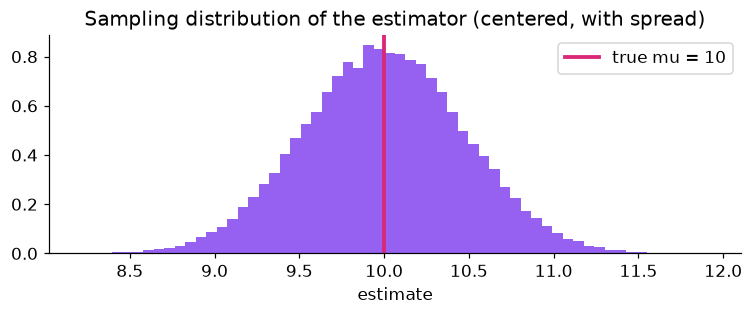

In [3]:
fig,ax=plt.subplots(figsize=(7,3))
ax.hist(estimates,bins=60,density=True,color=VIOLET,alpha=0.8)
ax.axvline(true_mu,color=PINK,lw=2.5,label="true mu = 10")
ax.set_title("Sampling distribution of the estimator (centered, with spread)"); ax.set_xlabel("estimate"); ax.legend()
plt.tight_layout(); plt.show()

The sample mean is an **unbiased** estimator: its sampling distribution is centered exactly on the true value 10. Its **variance** (here SE = 0.474) measures how much a single estimate would jump from sample to sample. A good estimator is both unbiased (or nearly so) and low-variance.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · A BIASED ESTIMATOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why we divide by n - 1</div>
<div style="color:#4a5578;margin-top:6px">Not every natural estimator is unbiased. Dividing the sum of squared deviations by n UNDER-estimates the variance; dividing by n-1 (Bessel's correction) fixes it.</div>
</div>

In [4]:
true_var, n = 4.0, 5
var_n   = np.array([rng.normal(0,2,size=n).var(ddof=0) for _ in range(100_000)])   # /n
var_nm1 = np.array([rng.normal(0,2,size=n).var(ddof=1) for _ in range(100_000)])   # /(n-1)
print(f"true variance        = {true_var}")
print(f"E[estimator with /n]    = {var_n.mean():.3f}  -> biased LOW (factor (n-1)/n = {(n-1)/n})")
print(f"E[estimator with /(n-1)]= {var_nm1.mean():.3f}  -> unbiased")

true variance        = 4.0
E[estimator with /n]    = 3.190  -> biased LOW (factor (n-1)/n = 0.8)
E[estimator with /(n-1)]= 3.995  -> unbiased


The /n estimator averages to 3.2, not 4: it is biased low by exactly (n&#8722;1)/n, because the sample mean is closer to the data than the true mean is. Dividing by **n &#8722; 1** removes the bias. This is why `np.var(ddof=1)` and the sample-variance formula use n &#8722; 1.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 3 · MAXIMUM LIKELIHOOD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The dominant estimation method</div>
<div style="color:#4a5578;margin-top:6px">Maximum likelihood picks the parameter that makes the observed data most probable. We maximize the log-likelihood; for many models the answer is a familiar statistic.</div>
</div>

In [5]:
data = rng.exponential(1/0.5, size=2000)      # true rate 0.5
grid = np.linspace(0.1, 1.5, 400)
# log-likelihood of exponential rate lambda: n*log(lambda) - lambda*sum(x)
loglik = len(data)*np.log(grid) - grid*data.sum()
mle = grid[np.argmax(loglik)]
print(f"MLE rate (argmax of log-likelihood) = {mle:.3f}")
print(f"closed form 1/mean                  = {1/data.mean():.3f}   (true 0.5)")

MLE rate (argmax of log-likelihood) = 0.521
closed form 1/mean                  = 0.520   (true 0.5)


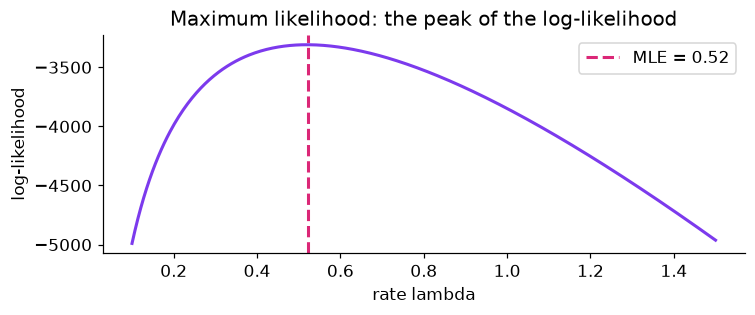

In [6]:
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(grid, loglik, color=VIOLET, lw=2)
ax.axvline(mle, color=PINK, ls="--", lw=2, label=f"MLE = {mle:.2f}")
ax.set_xlabel("rate lambda"); ax.set_ylabel("log-likelihood"); ax.set_title("Maximum likelihood: the peak of the log-likelihood"); ax.legend()
plt.tight_layout(); plt.show()

The log-likelihood peaks at the rate that best explains the data, and it matches the closed form 1/mean. **Maximum likelihood** is the workhorse of statistics: write down the probability of the data as a function of the parameter, then climb to its peak. Most estimators you know are MLEs in disguise.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 4 · CONSISTENCY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">More data, better estimates</div>
<div style="color:#4a5578;margin-top:6px">A consistent estimator converges to the true value as n grows. Maximum-likelihood estimators are consistent: the error shrinks toward zero with more data.</div>
</div>

In [7]:
true_rate = 0.5
for n in [10, 100, 1000, 10000, 100000]:
    ests = [1/rng.exponential(1/true_rate, size=n).mean() for _ in range(2000)]
    print(f"n={n:6d}: mean MLE = {np.mean(ests):.4f}, sd of MLE = {np.std(ests):.4f}")

n=    10: mean MLE = 0.5579, sd of MLE = 0.1886
n=   100: mean MLE = 0.5051, sd of MLE = 0.0494
n=  1000: mean MLE = 0.5005, sd of MLE = 0.0156
n= 10000: mean MLE = 0.5001, sd of MLE = 0.0052


n=100000: mean MLE = 0.5000, sd of MLE = 0.0016


As n grows the MLE homes in on 0.5 and its spread collapses (roughly like 1/sqrt(n)), the definition of **consistency**. Maximum-likelihood estimators are also **asymptotically efficient**: for large samples no consistent estimator has lower variance, they hit the theoretical floor (the Cramer-Rao bound).

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 5 · ESTIMATION IS MACHINE LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">MLE, MSE, and the bias-variance trade-off</div>
<div style="color:#4a5578;margin-top:6px">Training a model is estimation. Fitting a too-simple model gives high BIAS (underfitting); a too-flexible one gives high VARIANCE (overfitting). The art is balancing the two.</div>
</div>

In [8]:
def true_f(x): return np.sin(1.5*x)
xt = np.linspace(-2.3, 2.3, 60); yt = true_f(xt)      # interior test grid
reps = 300
for degree in [1, 3, 5, 12]:
    errs = []
    for _ in range(reps):
        x = rng.uniform(-3, 3, 25); y = true_f(x) + rng.normal(0, 0.3, 25)
        coef = np.polyfit(x, y, degree)
        errs.append(np.mean((np.polyval(coef, xt) - yt)**2))      # test MSE vs truth
    label = "underfit (high bias)" if degree==1 else "overfit (high variance)" if degree==12 else "good fit"
    print(f"degree {degree:2d}: average test MSE = {np.mean(errs):.4f}   {label}")

degree  1: average test MSE = 0.4843   underfit (high bias)
degree  3: average test MSE = 0.0740   good fit
degree  5: average test MSE = 0.0244   good fit
degree 12: average test MSE = 83.0596   overfit (high variance)


The low-degree fit is too rigid: high **bias**, low variance. The high-degree fit chases the noise: low bias, high **variance**. The middle degree minimizes their sum, the **bias-variance trade-off** that governs every model's complexity. Training itself is **maximum likelihood**: minimizing cross-entropy is maximizing a Bernoulli likelihood, and minimizing squared error is maximizing a Gaussian likelihood. Estimation theory is the theory of machine learning.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You measured an estimator's bias and variance, saw why we divide by n-1, derived a maximum-likelihood estimate, watched it converge with more data, and traced the bias-variance trade-off that controls model complexity. Estimation theory is where mathematical statistics becomes machine learning, and it closes Part VIII.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>